In [2]:
!chmod 600 kaggle.json
!kaggle competitions download -c home-credit-default-risk
!unzip home-credit-default-risk.zip

chmod: cannot access 'kaggle.json': No such file or directory
100% 688M/688M [00:02<00:00, 292MB/s]

Archive:  home-credit-default-risk.zip
  inflating: HomeCredit_columns_description.csv  
  inflating: POS_CASH_balance.csv    
  inflating: application_test.csv    
  inflating: application_train.csv   
  inflating: bureau.csv              
  inflating: bureau_balance.csv      
  inflating: credit_card_balance.csv  
  inflating: installments_payments.csv  
  inflating: previous_application.csv  
  inflating: sample_submission.csv   


# Exploratory Data Analysis (EDA)
## Home Credit Default Risk — CO3117 Machine Learning

**Mục tiêu EDA:**
1. Hiểu cấu trúc & kích thước từng bảng dữ liệu
2. Phân tích biến mục tiêu (TARGET) — class imbalance
3. Phân tích missing values
4. Phân tích phân phối các biến quan trọng
5. Tương quan giữa features và TARGET
6. Phân tích các bảng phụ (bureau, previous_application, v.v.)

In [3]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Matplotlib style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']


def p(filename): return os.path.join('/content', filename)

---

## SECTION 1 — Dataset Overview

In [4]:
# Load All Data Tables
print('Loading datasets (this may take a moment)...')

app_train       = pd.read_csv(p('application_train.csv'))
bureau          = pd.read_csv(p('bureau.csv'))
bureau_balance  = pd.read_csv(p('bureau_balance.csv'))
prev_app        = pd.read_csv(p('previous_application.csv'))
installments    = pd.read_csv(p('installments_payments.csv'))
credit_card     = pd.read_csv(p('credit_card_balance.csv'))
pos_cash        = pd.read_csv(p('POS_CASH_balance.csv'))

datasets = {
    'application_train':    app_train,
    'bureau':               bureau,
    'bureau_balance':       bureau_balance,
    'previous_application': prev_app,
    'installments_payments':installments,
    'credit_card_balance':  credit_card,
    'POS_CASH_balance':     pos_cash,
}

join_keys = {
    'application_train':    'SK_ID_CURR',
    'bureau':               'SK_ID_CURR',
    'bureau_balance':       'SK_ID_BUREAU',
    'previous_application': 'SK_ID_CURR',
    'installments_payments':'SK_ID_CURR',
    'credit_card_balance':  'SK_ID_CURR',
    'POS_CASH_balance':     'SK_ID_CURR',
}

summary = []
for name, df in datasets.items():
    n_missing = df.isnull().sum().sum()
    pct_missing = 100 * n_missing / df.size
    summary.append({
        'Table': name,
        'Rows': f'{len(df):,}',
        'Columns': df.shape[1],
        'Join Key': join_keys[name],
        'Missing Values': f'{n_missing:,}',
        'Missing %': f'{pct_missing:.1f}%',
    })

summary_df = pd.DataFrame(summary)
print('\n Dataset Summary:')
display(summary_df.set_index('Table'))

Loading datasets (this may take a moment)...

 Dataset Summary:


,Rows,Columns,Join Key,Missing Values,Missing %
Table,,,,,
application_train,"307,511",122,SK_ID_CURR,"9,152,465",24.4%
bureau,"1,716,428",17,SK_ID_CURR,"3,939,947",13.5%
bureau_balance,"27,299,925",3,SK_ID_BUREAU,0,0.0%
previous_application,"1,670,214",37,SK_ID_CURR,"11,109,336",18.0%
installments_payments,"13,605,401",8,SK_ID_CURR,"5,810",0.0%
credit_card_balance,"3,840,312",23,SK_ID_CURR,"5,877,356",6.7%
POS_CASH_balance,"10,001,358",8,SK_ID_CURR,"52,158",0.1%


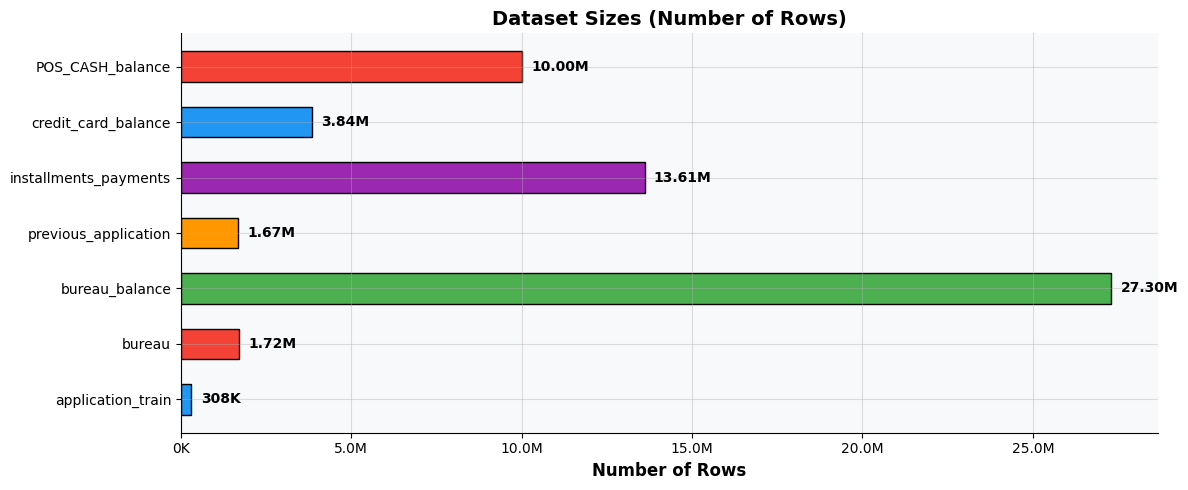

In [5]:
# Visualize dataset sizes
names  = list(datasets.keys())
n_rows = [len(df) for df in datasets.values()]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(names, n_rows, color=PALETTE * 2, edgecolor='black', height=0.55)
ax.set_xlabel('Number of Rows', fontsize=12, fontweight='bold')
ax.set_title('Dataset Sizes (Number of Rows)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))
for bar, v in zip(bars, n_rows):
    label = f'{v/1e6:.2f}M' if v >= 1e6 else f'{v/1e3:.0f}K'
    ax.text(bar.get_width() + max(n_rows)*0.01, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(p('eda_dataset_sizes.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## SECTION 2 — Target Variable Analysis (Class Imbalance)
**TARGET = 1**: Khách hàng vỡ nợ | **TARGET = 0**: Trả đúng hạn

TARGET Distribution
Class 0 (No Default):  282,686 (91.93%)
Class 1 (Default):      24,825 (8.07%)

Imbalance ratio: 11.39:1



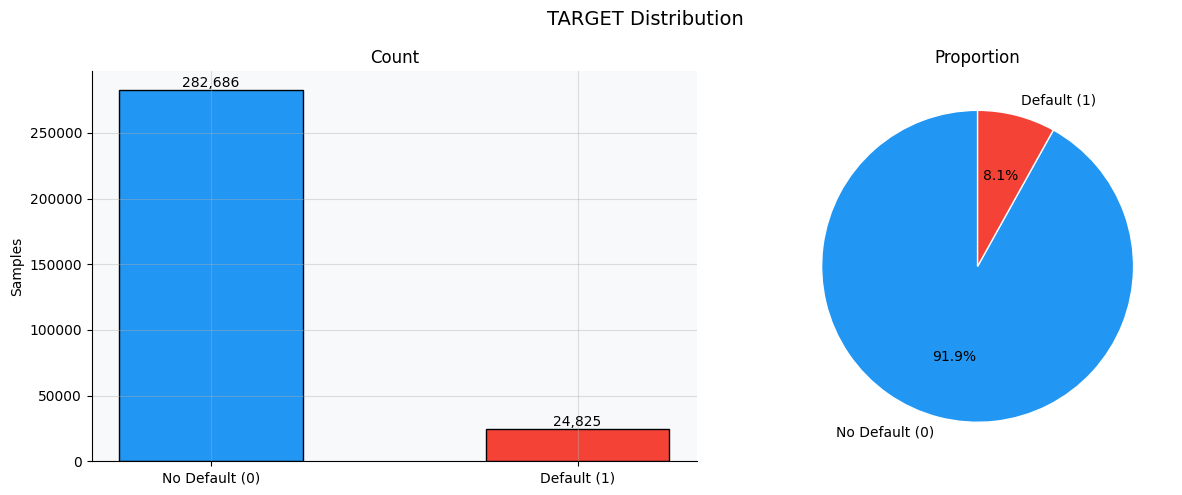

In [6]:
target_counts = app_train['TARGET'].value_counts().sort_index()
target_pct    = app_train['TARGET'].value_counts(normalize=True).sort_index() * 100

print('=' * 40)
print('TARGET Distribution')
print('=' * 40)
print(f'Class 0 (No Default): {target_counts[0]:>8,} ({target_pct[0]:.2f}%)')
print(f'Class 1 (Default):    {target_counts[1]:>8,} ({target_pct[1]:.2f}%)')

imbalance_ratio = target_counts[0] / target_counts[1]
print(f'\nImbalance ratio: {imbalance_ratio:.2f}:1')
print()

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('TARGET Distribution', fontsize=14)

colors = ['#2196F3', '#F44336']
labels = ['No Default (0)', 'Default (1)']

# Bar chart
bars = axes[0].bar(labels, target_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Count')
axes[0].set_ylabel('Samples')

for bar, v in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{v:,}', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(
    target_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig(p('eda_target_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## SECTION 3 — Missing Value Analysis

In [7]:
# Missing value analysis for application_train
missing = app_train.isnull().sum()
missing_pct = 100 * missing / len(app_train)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'application_train: {len(app_train.columns)} columns total')
print(f'  Columns with missing values: {len(missing_df)}')
print(f'  Columns complete (no missing): {len(app_train.columns) - len(missing_df)}')

# Categorize
high_miss  = missing_df[missing_df['Missing %'] >= 50]
med_miss   = missing_df[(missing_df['Missing %'] >= 20) & (missing_df['Missing %'] < 50)]
low_miss   = missing_df[missing_df['Missing %'] < 20]

print(f'\n  • High missing (≥50%): {len(high_miss)} columns')
print(f'  • Medium missing (20-50%): {len(med_miss)} columns')
print(f'  • Low missing (<20%): {len(low_miss)} columns')

application_train: 122 columns total
  Columns with missing values: 67
  Columns complete (no missing): 55

  • High missing (≥50%): 41 columns
  • Medium missing (20-50%): 9 columns
  • Low missing (<20%): 17 columns


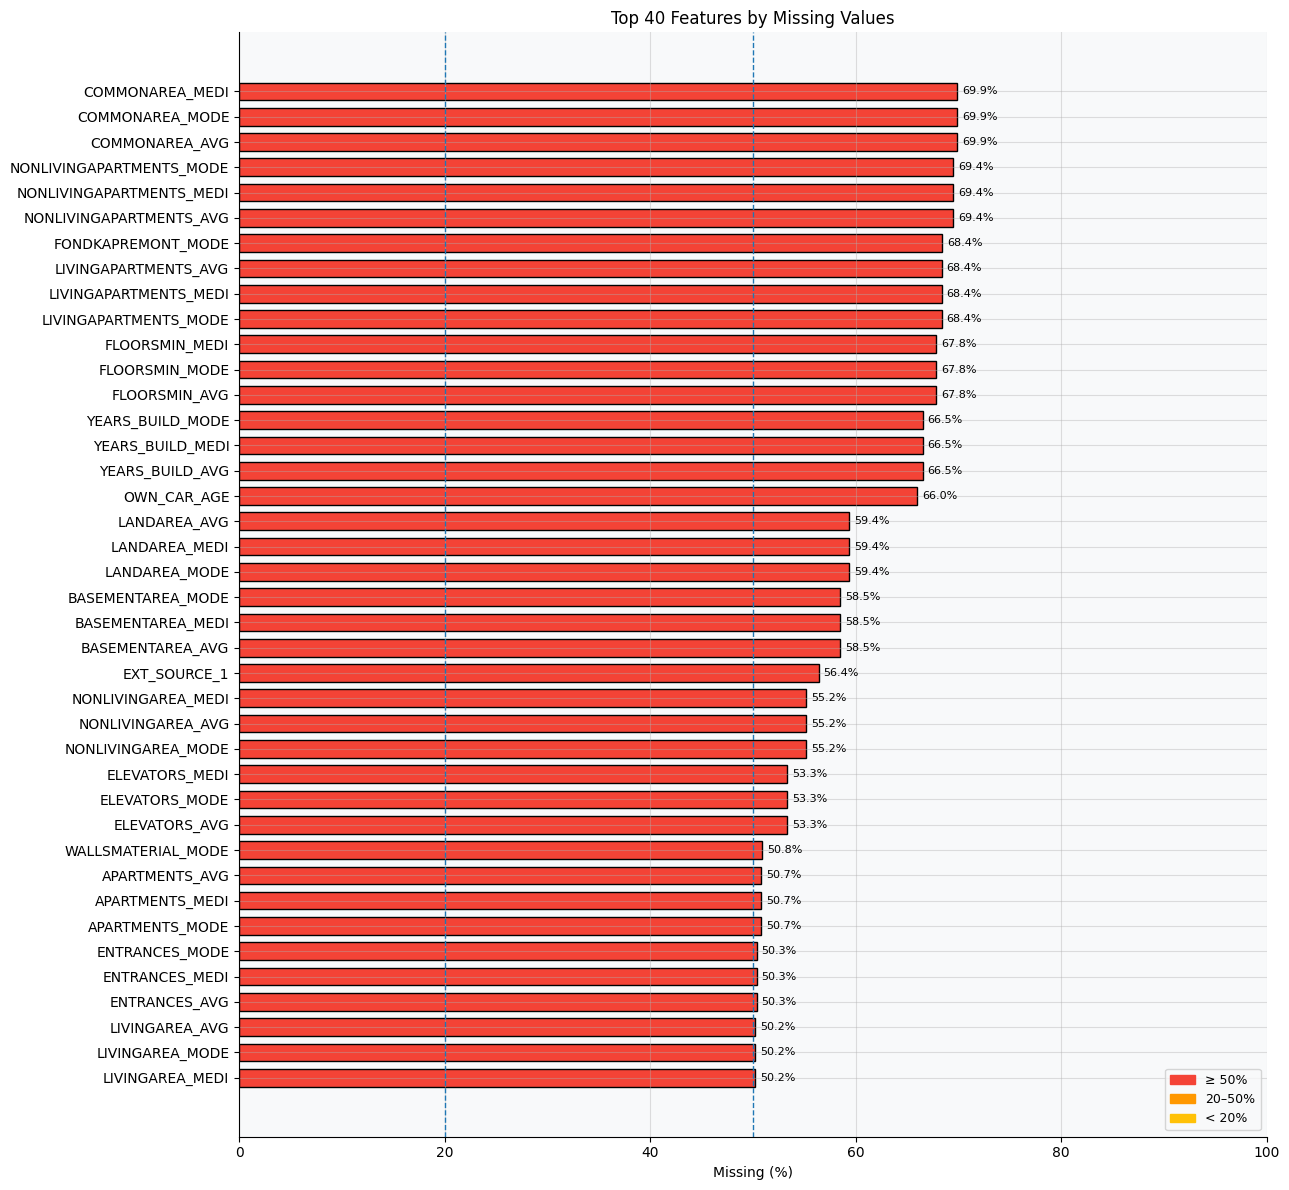

In [8]:
# Top 40 columns with most missing values
top_miss = missing_df.head(40)

fig, ax = plt.subplots(figsize=(13, 12))

def missing_color(pct):
    if pct >= 50:
        return '#F44336'
    elif pct >= 20:
        return '#FF9800'
    else:
        return '#FFC107'

colors = [missing_color(p) for p in top_miss['Missing %']]

bars = ax.barh(
    top_miss.index[::-1],
    top_miss['Missing %'][::-1],
    color=colors[::-1],
    edgecolor='black',
    height=0.7
)

# Threshold lines
ax.axvline(50, linestyle='--', linewidth=1)
ax.axvline(20, linestyle='--', linewidth=1)

# Value labels
for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{w:.1f}%',
        va='center',
        fontsize=8
    )

# Legend
patches = [
    mpatches.Patch(color='#F44336', label='≥ 50%'),
    mpatches.Patch(color='#FF9800', label='20–50%'),
    mpatches.Patch(color='#FFC107', label='< 20%')
]
ax.legend(handles=patches, loc='lower right', fontsize=9)

ax.set_xlabel('Missing (%)')
ax.set_title('Top 40 Features by Missing Values')
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig(p('eda_missing_values.png'), dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# EXT_SOURCE missing analysis
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

print('EXT_SOURCE Missing Analysis')
print('-' * 35)

for col in ext_cols:
    n = app_train[col].isnull().sum()
    pct = 100 * n / len(app_train)
    print(f'{col}: {n:,} ({pct:.1f}%)')

# Rows with missing values
all_missing = app_train[ext_cols].isnull().all(axis=1).sum()
any_missing = app_train[ext_cols].isnull().any(axis=1).sum()

print('\nRows with missing values:')
print(f'All 3 missing: {all_missing:,} ({100*all_missing/len(app_train):.1f}%)')
print(f'Any missing:   {any_missing:,} ({100*any_missing/len(app_train):.1f}%)')

print('\nHandling:')
print('- Fill with median or a constant (e.g., -999)')

EXT_SOURCE Missing Analysis
-----------------------------------
EXT_SOURCE_1: 173,378 (56.4%)
EXT_SOURCE_2: 660 (0.2%)
EXT_SOURCE_3: 60,965 (19.8%)

Rows with missing values:
All 3 missing: 172 (0.1%)
Any missing:   197,922 (64.4%)

Handling:
- Fill with median or a constant (e.g., -999)


### 4.1 Anomaly Detection: DAYS_EMPLOYED

Trong quá trình khám phá dữ liệu, chúng ta phát hiện một giá trị bất thường trong cột `DAYS_EMPLOYED`: **365243**.
Giá trị này tương đương với khoảng 1000 năm, một con số phi thực tế đối với thời gian làm việc của con người.

Dưới đây chúng ta sẽ phân tích tỉ lệ nợ xấu (`TARGET`) của nhóm có giá trị này so với nhóm còn lại để hiểu tại sao chúng ta cần xử lý nó trong Pipeline Feature Engineering.

Số lượng bản ghi bất thường: 55374
Tỉ lệ nợ xấu của nhóm Anomalies: 5.40%
Tỉ lệ nợ xấu của nhóm Normal: 8.66%


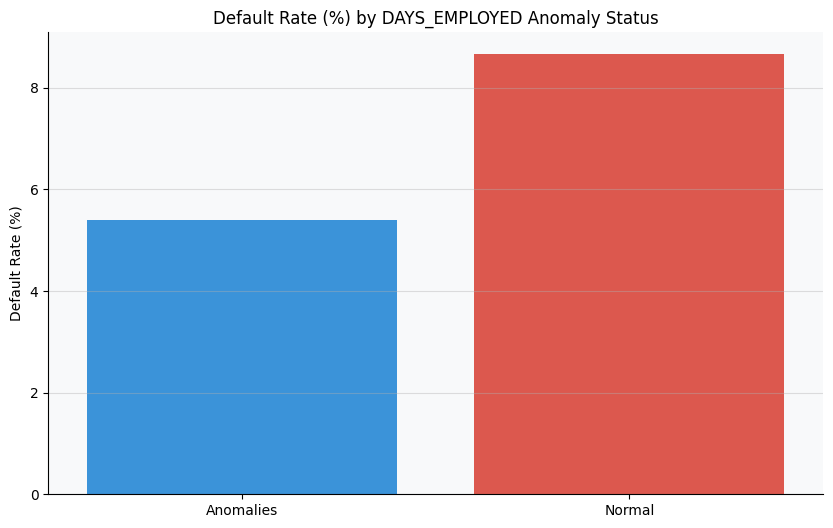

In [10]:
# Tạo flag cho các giá trị bất thường
app_train['DAYS_EMPLOYED_ANOM'] = app_train['DAYS_EMPLOYED'] == 365243

anom = app_train[app_train['DAYS_EMPLOYED_ANOM'] == True]
non_anom = app_train[app_train['DAYS_EMPLOYED_ANOM'] == False]

print(f'Số lượng bản ghi bất thường: {len(anom)}')
print(f"Tỉ lệ nợ xấu của nhóm Anomalies: {100 * anom['TARGET'].mean():.2f}%")
print(f"Tỉ lệ nợ xấu của nhóm Normal: {100 * non_anom['TARGET'].mean():.2f}%")

# Trực quan hóa
plt.figure(figsize=(10, 6))
sns.barplot(x=['Anomalies', 'Normal'], y=[anom['TARGET'].mean()*100, non_anom['TARGET'].mean()*100], palette=PALETTE)
plt.title('Default Rate (%) by DAYS_EMPLOYED Anomaly Status')
plt.ylabel('Default Rate (%)')
plt.show()

### 4.2 Neighborhood Analysis (Lý do sử dụng KNN)

Các biến `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3` là những đặc trưng có khả năng dự báo mạnh nhất.
Ý tưởng của **Neighborhood Analysis** là những khách hàng có điểm số tín dụng từ các nguồn bên ngoài tương tự nhau sẽ có xác suất vỡ nợ tương đồng.

Điều này giải thích tại sao trong Pipeline chúng ta sử dụng thuật toán KNN để trích xuất các đặc trưng lân cận dựa trên 3 biến này.

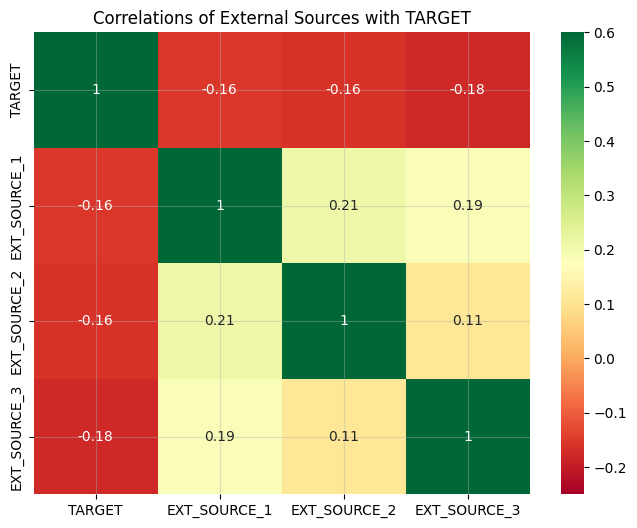

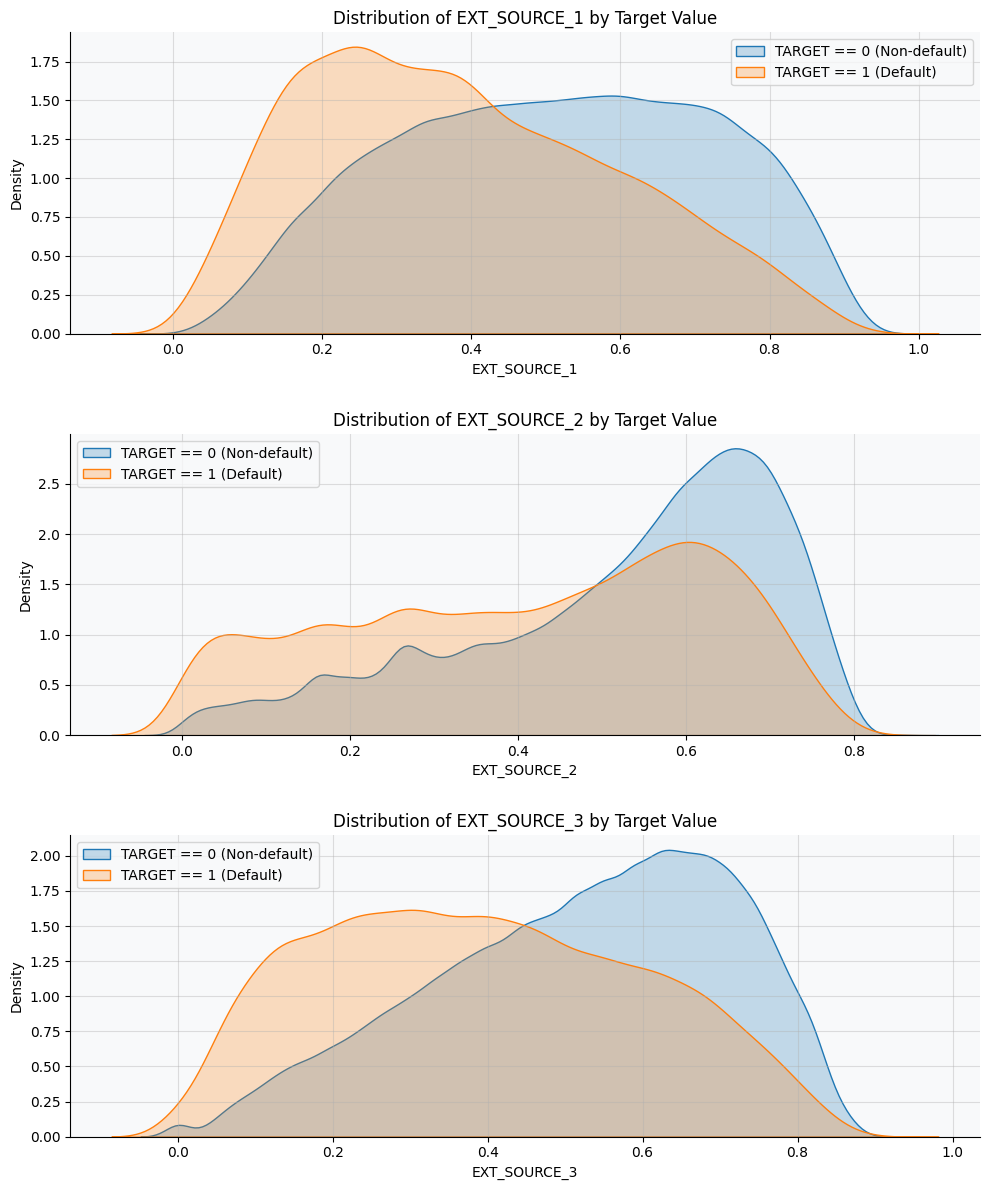

In [11]:
# Phân tích tương quan của EXT_SOURCE với TARGET
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']]
ext_data_corrs = ext_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(ext_data_corrs, annot=True, cmap='RdYlGn', vmin=-0.25, vmax=0.6)
plt.title('Correlations of External Sources with TARGET')
plt.show()

# Phân phối EXT_SOURCE theo TARGET
plt.figure(figsize=(10, 12))
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    plt.subplot(3, 1, i + 1)
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, source], label='TARGET == 0 (Non-default)', shade=True)
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, source], label='TARGET == 1 (Default)', shade=True)
    plt.title(f'Distribution of {source} by Target Value')
    plt.xlabel(source)
    plt.ylabel('Density')
    plt.legend()
plt.tight_layout(h_pad=2.5)
plt.show()

---

## SECTION 4 — Distribution of Key Numerical Features

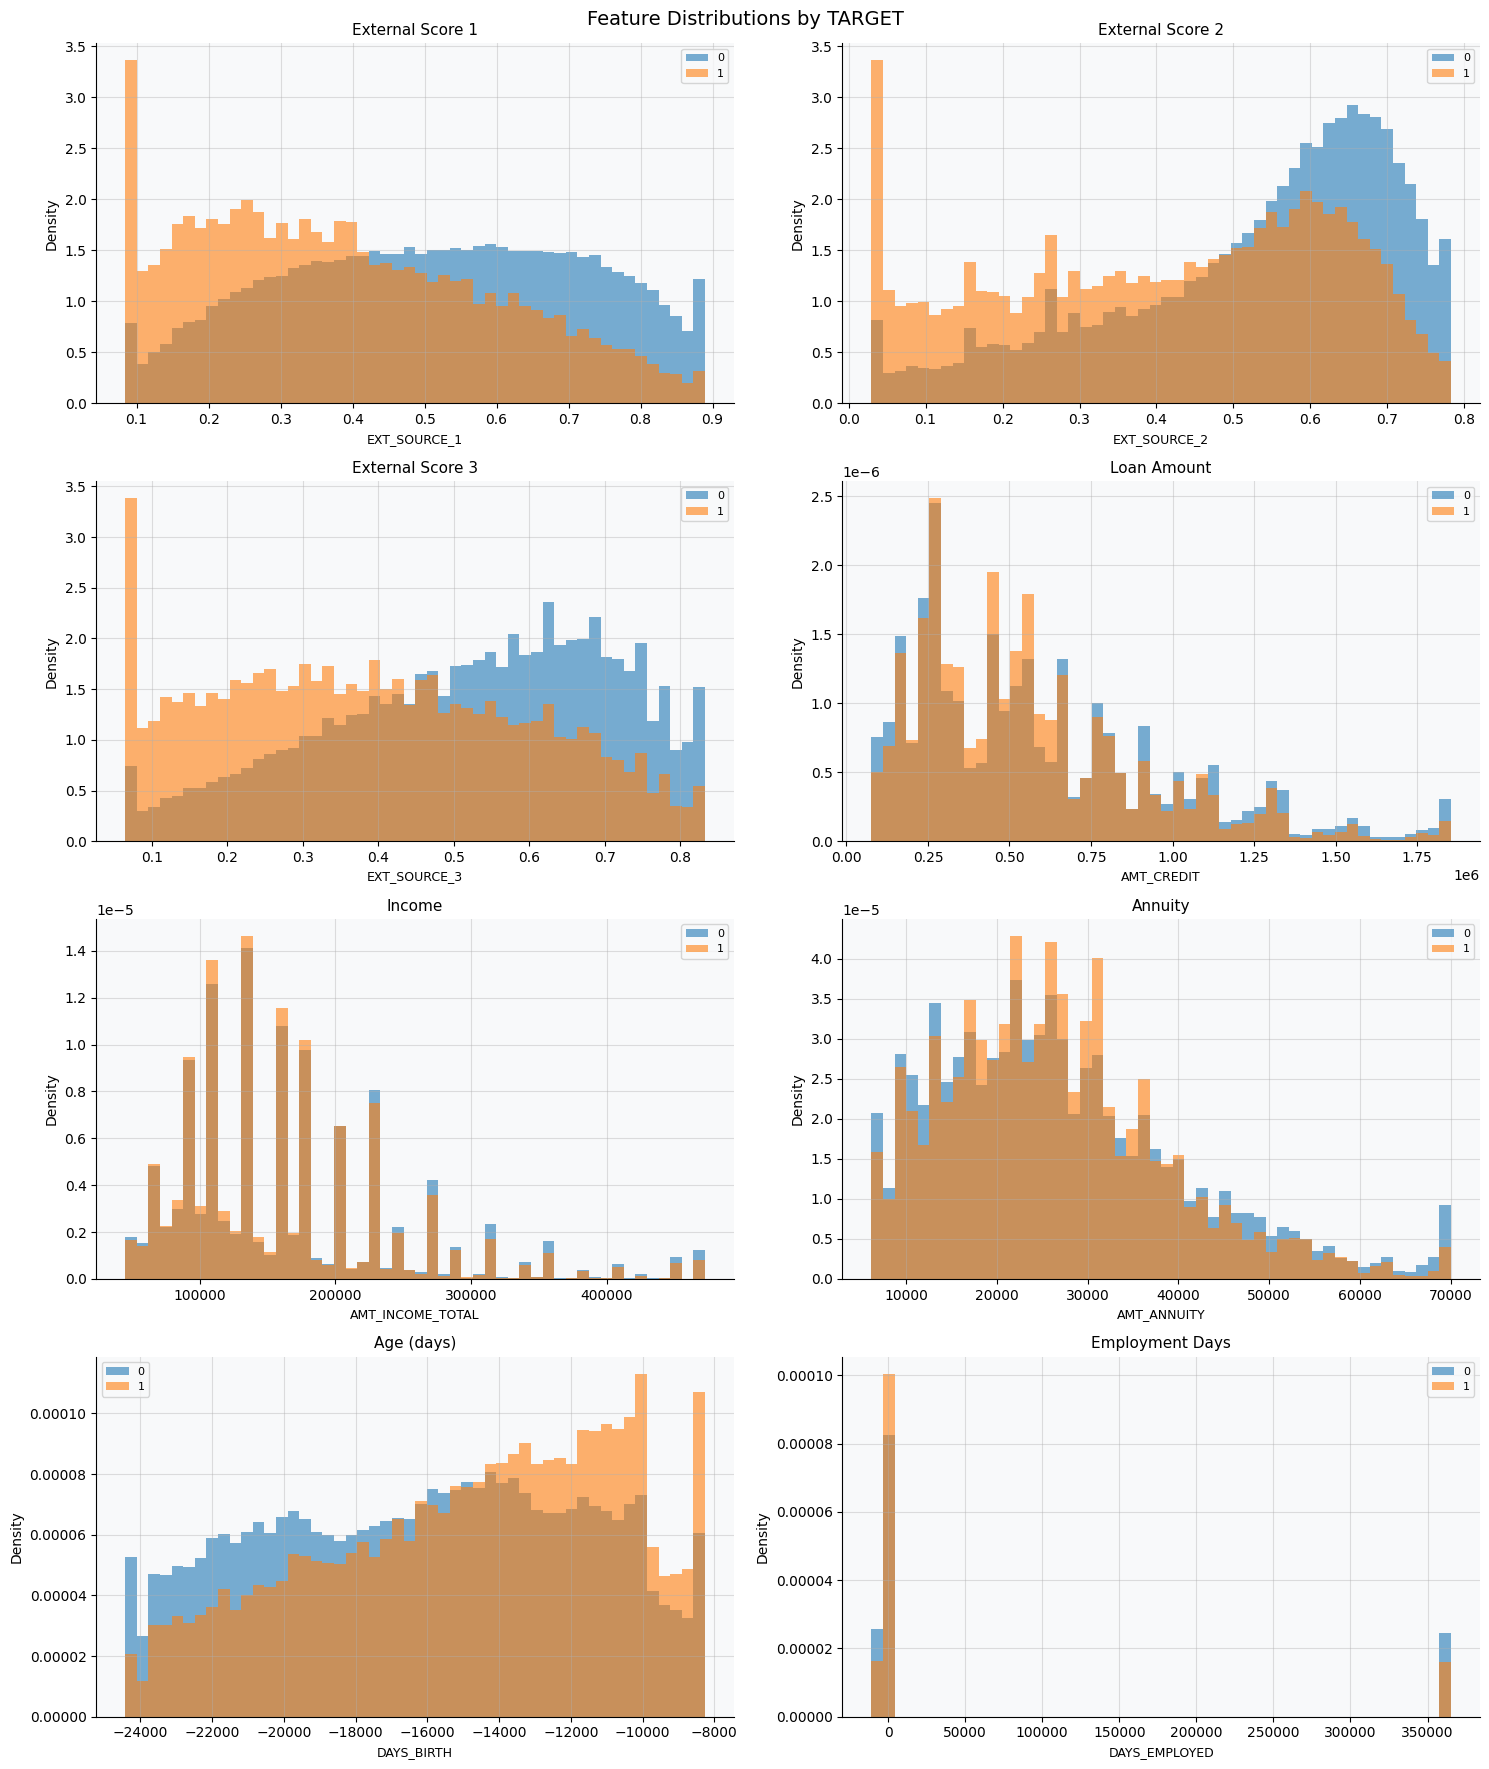

In [12]:
# Distribution by TARGET
key_num_features = [
    ('EXT_SOURCE_1', 'External Score 1'),
    ('EXT_SOURCE_2', 'External Score 2'),
    ('EXT_SOURCE_3', 'External Score 3'),
    ('AMT_CREDIT', 'Loan Amount'),
    ('AMT_INCOME_TOTAL', 'Income'),
    ('AMT_ANNUITY', 'Annuity'),
    ('DAYS_BIRTH', 'Age (days)'),
    ('DAYS_EMPLOYED', 'Employment Days'),
]

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()
fig.suptitle('Feature Distributions by TARGET', fontsize=14)

for i, (col, title) in enumerate(key_num_features):
    ax = axes[i]

    data0 = app_train.loc[app_train['TARGET'] == 0, col].dropna()
    data1 = app_train.loc[app_train['TARGET'] == 1, col].dropna()

    # Clip outliers for visualization
    q01, q99 = app_train[col].dropna().quantile([0.01, 0.99])
    data0 = data0.clip(q01, q99)
    data1 = data1.clip(q01, q99)

    ax.hist(data0, bins=50, alpha=0.6, label='0', density=True)
    ax.hist(data1, bins=50, alpha=0.6, label='1', density=True)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(p('eda_feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

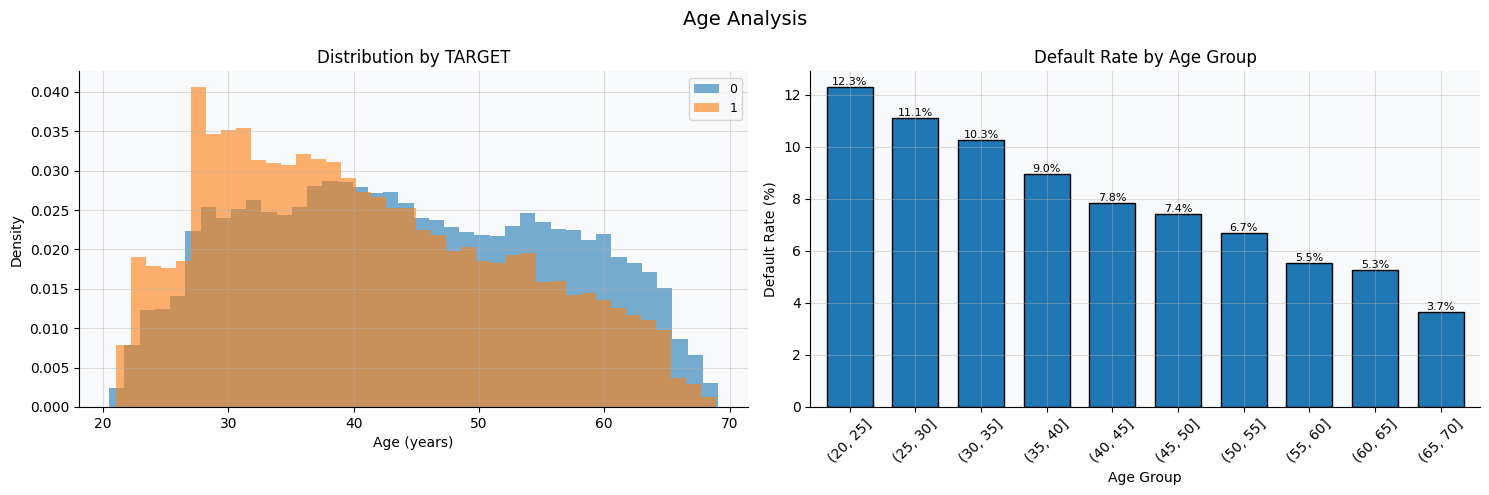

In [13]:
# Age analysis
app_train['AGE_YEARS'] = -app_train['DAYS_BIRTH'] / 365.25

age_bins = pd.cut(app_train['AGE_YEARS'], bins=range(20, 75, 5))
age_default_rate = app_train.groupby(age_bins, observed=True)['TARGET'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Age Analysis', fontsize=14)

# Distribution
axes[0].hist(
    app_train.loc[app_train['TARGET'] == 0, 'AGE_YEARS'],
    bins=40, alpha=0.6, density=True, label='0'
)
axes[0].hist(
    app_train.loc[app_train['TARGET'] == 1, 'AGE_YEARS'],
    bins=40, alpha=0.6, density=True, label='1'
)

axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution by TARGET')
axes[0].legend(fontsize=9)

# Default rate by age group
age_default_rate.plot(
    kind='bar',
    ax=axes[1],
    edgecolor='black',
    width=0.7
)

axes[1].set_title('Default Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Default Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

for bar in axes[1].patches:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        h,
        f'{h:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.savefig(p('eda_age_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## SECTION 5 — Categorical Features Analysis

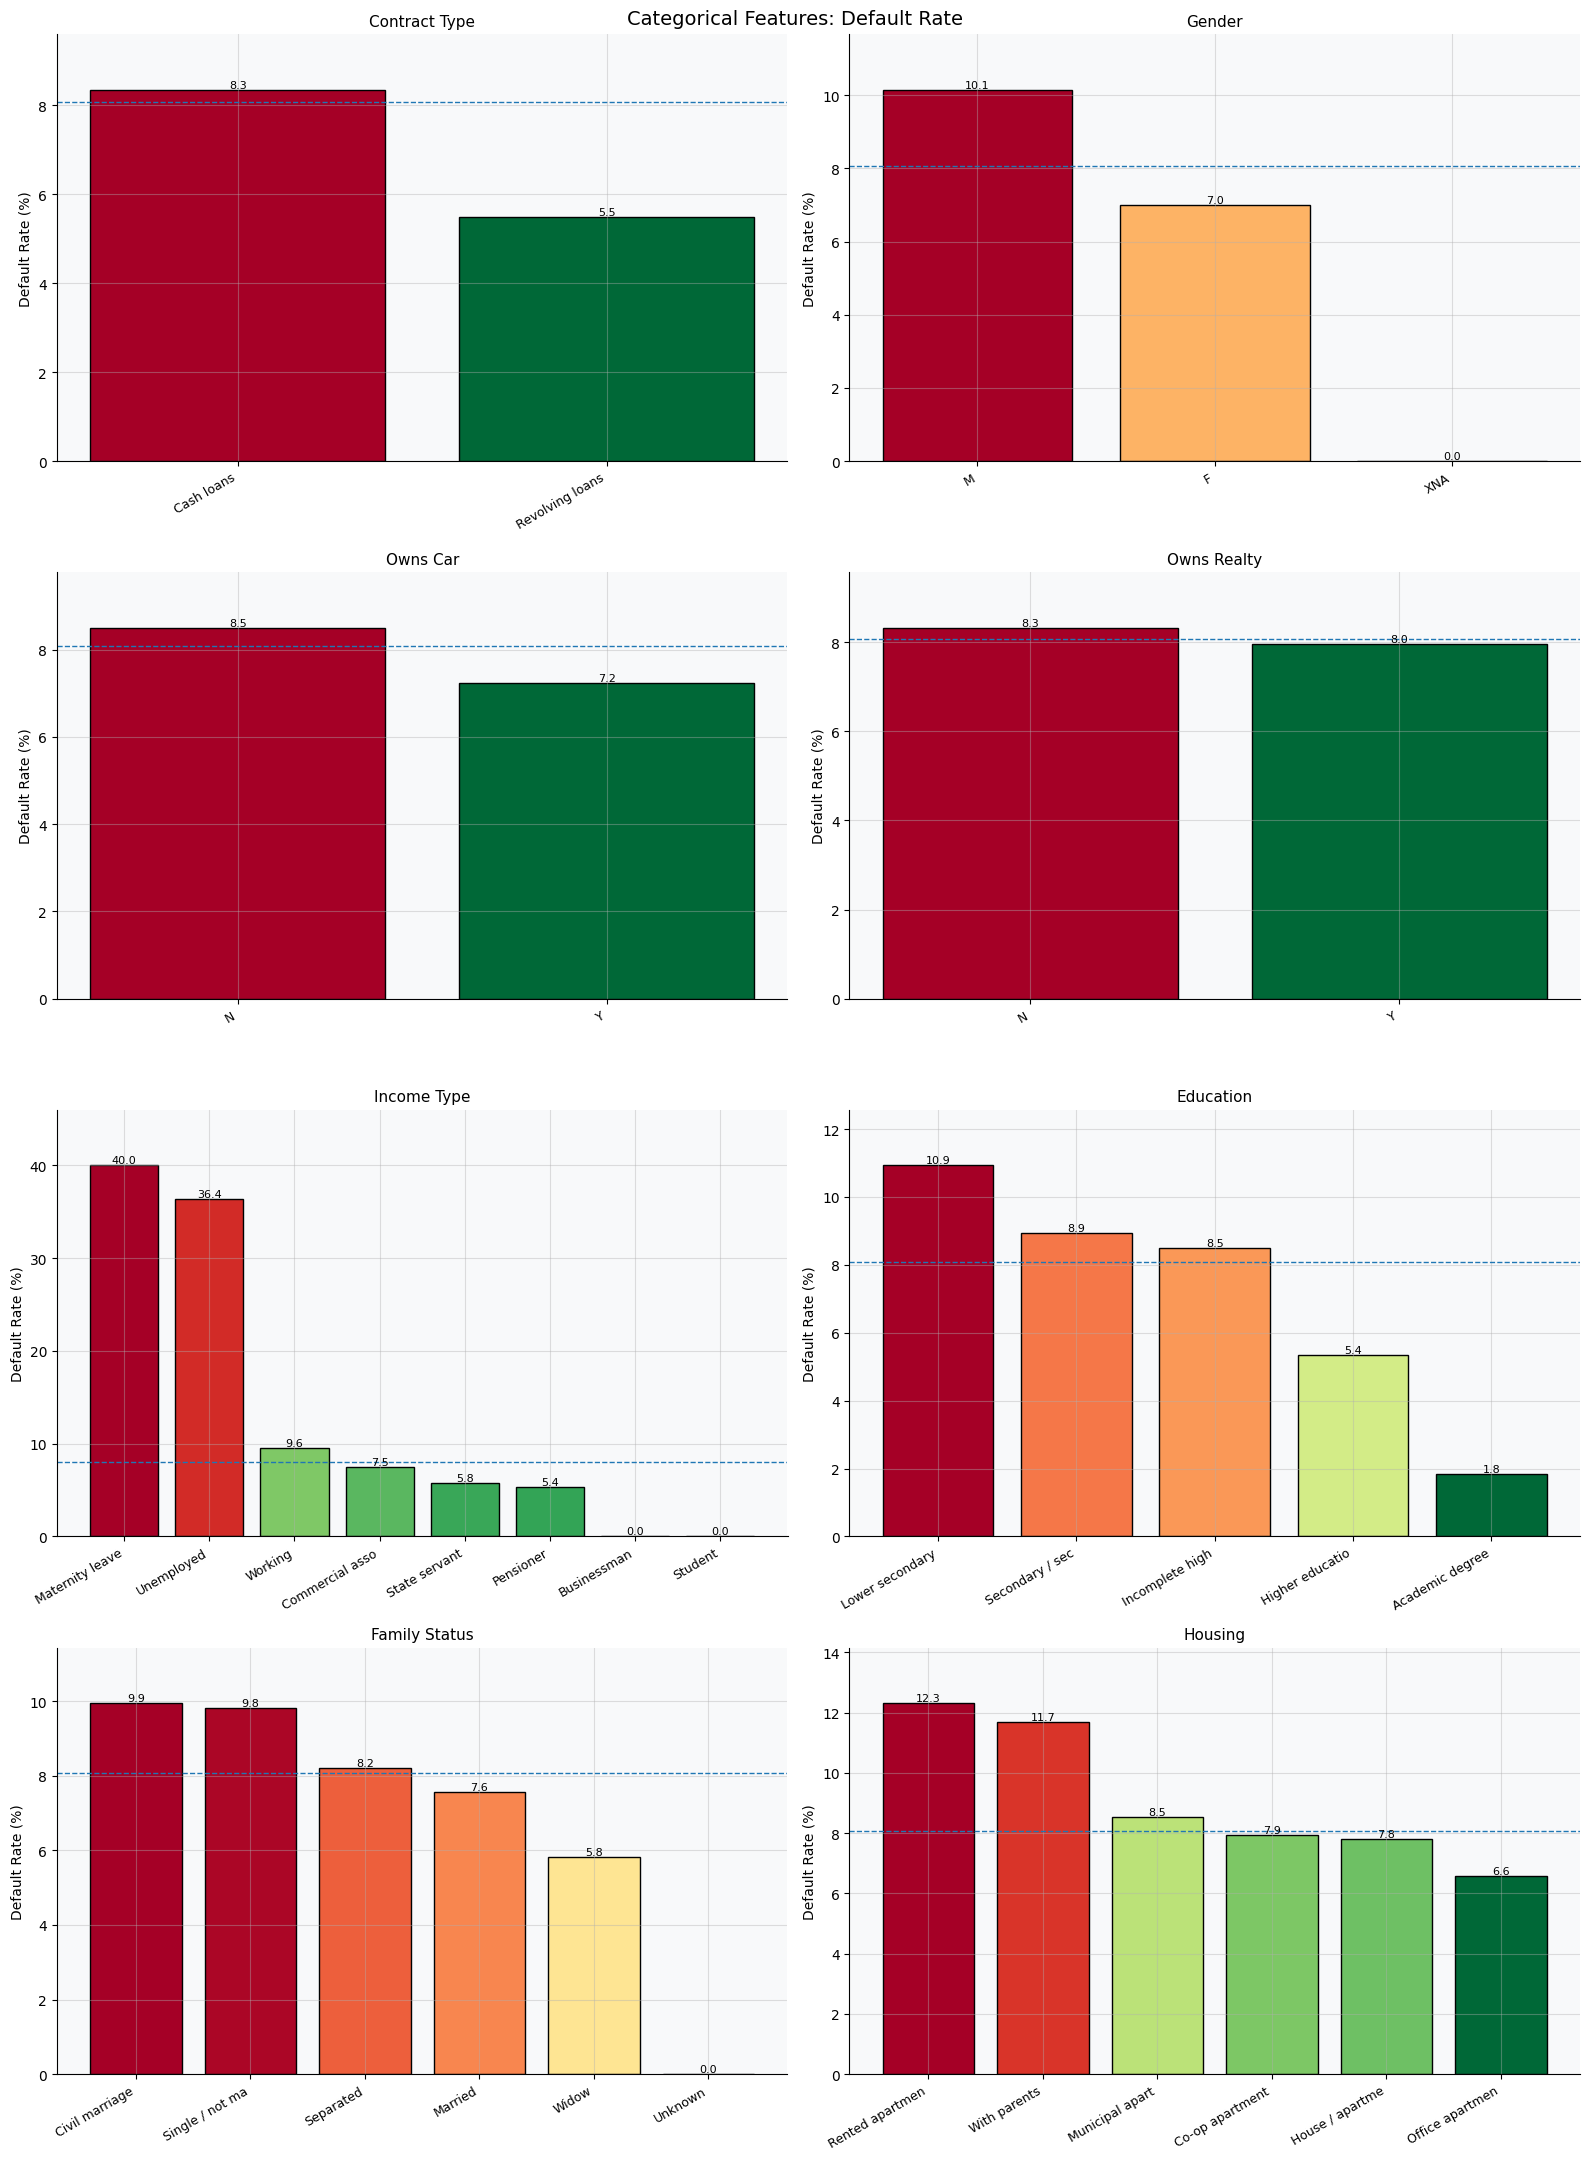

In [14]:
cat_features = [
    ('NAME_CONTRACT_TYPE',   'Contract Type'),
    ('CODE_GENDER',          'Gender'),
    ('FLAG_OWN_CAR',         'Owns Car'),
    ('FLAG_OWN_REALTY',      'Owns Realty'),
    ('NAME_INCOME_TYPE',     'Income Type'),
    ('NAME_EDUCATION_TYPE',  'Education'),
    ('NAME_FAMILY_STATUS',   'Family Status'),
    ('NAME_HOUSING_TYPE',    'Housing'),
]

fig, axes = plt.subplots(4, 2, figsize=(16, 22))
axes = axes.flatten()
fig.suptitle('Categorical Features: Default Rate', fontsize=14)

overall_rate = app_train['TARGET'].mean() * 100

for i, (col, title) in enumerate(cat_features):
    ax = axes[i]

    grp = (
        app_train.groupby(col, observed=True)['TARGET']
        .agg(['mean', 'count'])
        .reset_index()
    )
    grp.columns = [col, 'default_rate', 'count']
    grp['default_rate'] *= 100
    grp = grp.sort_values('default_rate', ascending=False)

    # Color mapping
    cmap = plt.cm.RdYlGn_r
    norm = (grp['default_rate'] - grp['default_rate'].min()) / \
           (grp['default_rate'].max() - grp['default_rate'].min() + 1e-9)
    colors = [cmap(v) for v in norm]

    bars = ax.bar(range(len(grp)), grp['default_rate'],
                  color=colors, edgecolor='black')

    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels([str(x)[:15] for x in grp[col]],
                       rotation=30, ha='right', fontsize=9)

    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Default Rate (%)')

    # Overall reference line
    ax.axhline(overall_rate, linestyle='--', linewidth=1)
    ax.set_ylim(0, grp['default_rate'].max() * 1.15)

    # Value labels
    for bar, v in zip(bars, grp['default_rate']):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            v,
            f'{v:.1f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.tight_layout()
plt.savefig(p('eda_categorical_features.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## SECTION 6 — Correlation Analysis

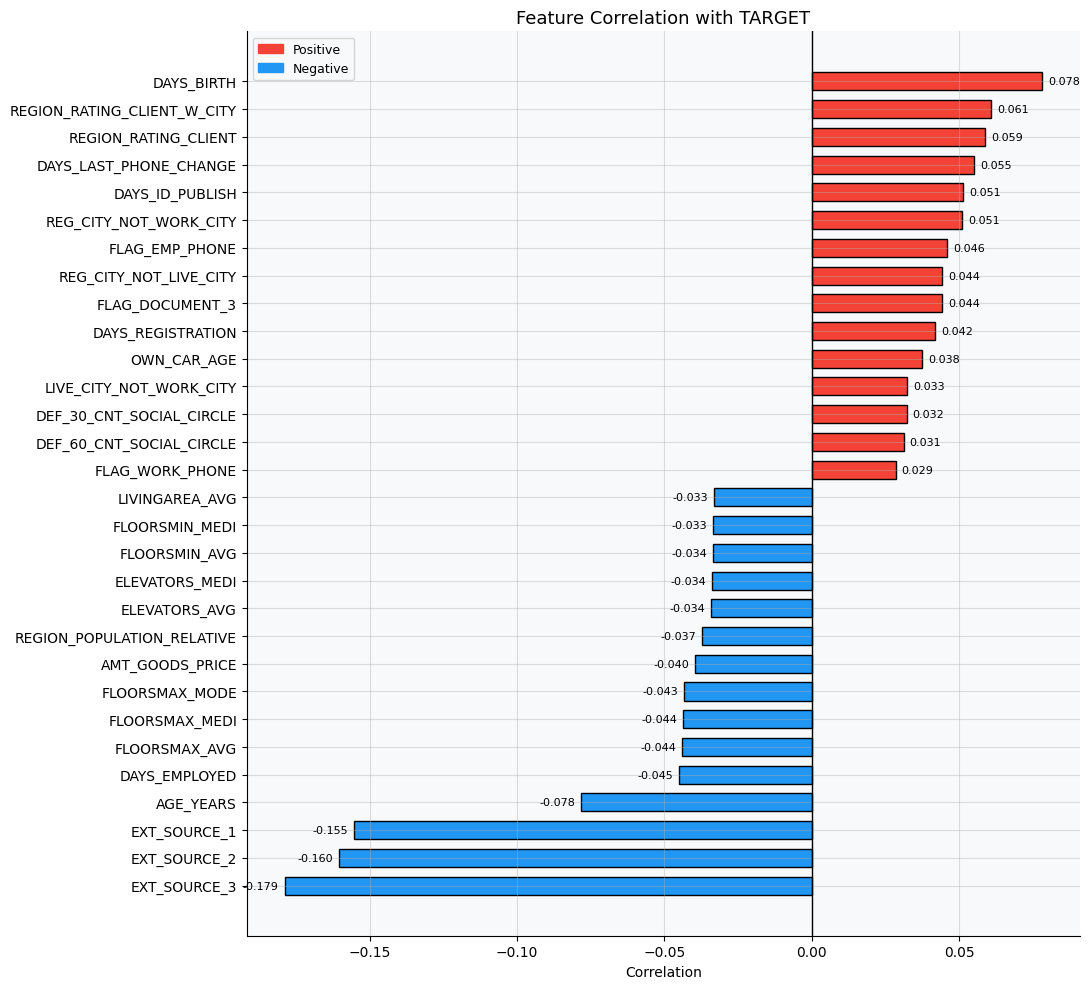

In [15]:
# Correlation with TARGET
num_cols = app_train.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = (
    app_train[num_cols].corr()['TARGET']
    .drop('TARGET')
    .sort_values()
)

# Top features
top_pos = corr_with_target.tail(15)
top_neg = corr_with_target.head(15)
top_corr = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(11, 10))

colors = ['#2196F3' if v < 0 else '#F44336' for v in top_corr.values]
bars = ax.barh(
    top_corr.index,
    top_corr.values,
    color=colors,
    edgecolor='black',
    height=0.65
)

ax.axvline(0, color='black', linewidth=1)
ax.set_title('Feature Correlation with TARGET', fontsize=13)
ax.set_xlabel('Correlation')

# Legend
patches = [
    mpatches.Patch(color='#F44336', label='Positive'),
    mpatches.Patch(color='#2196F3', label='Negative')
]
ax.legend(handles=patches, fontsize=9)

# Value labels
for bar, v in zip(bars, top_corr.values):
    offset = 0.002 if v >= 0 else -0.002
    ha = 'left' if v >= 0 else 'right'
    ax.text(
        v + offset,
        bar.get_y() + bar.get_height()/2,
        f'{v:.3f}',
        va='center',
        ha=ha,
        fontsize=8
    )

plt.tight_layout()
plt.savefig(p('eda_correlation_target.png'), dpi=150, bbox_inches='tight')
plt.show()

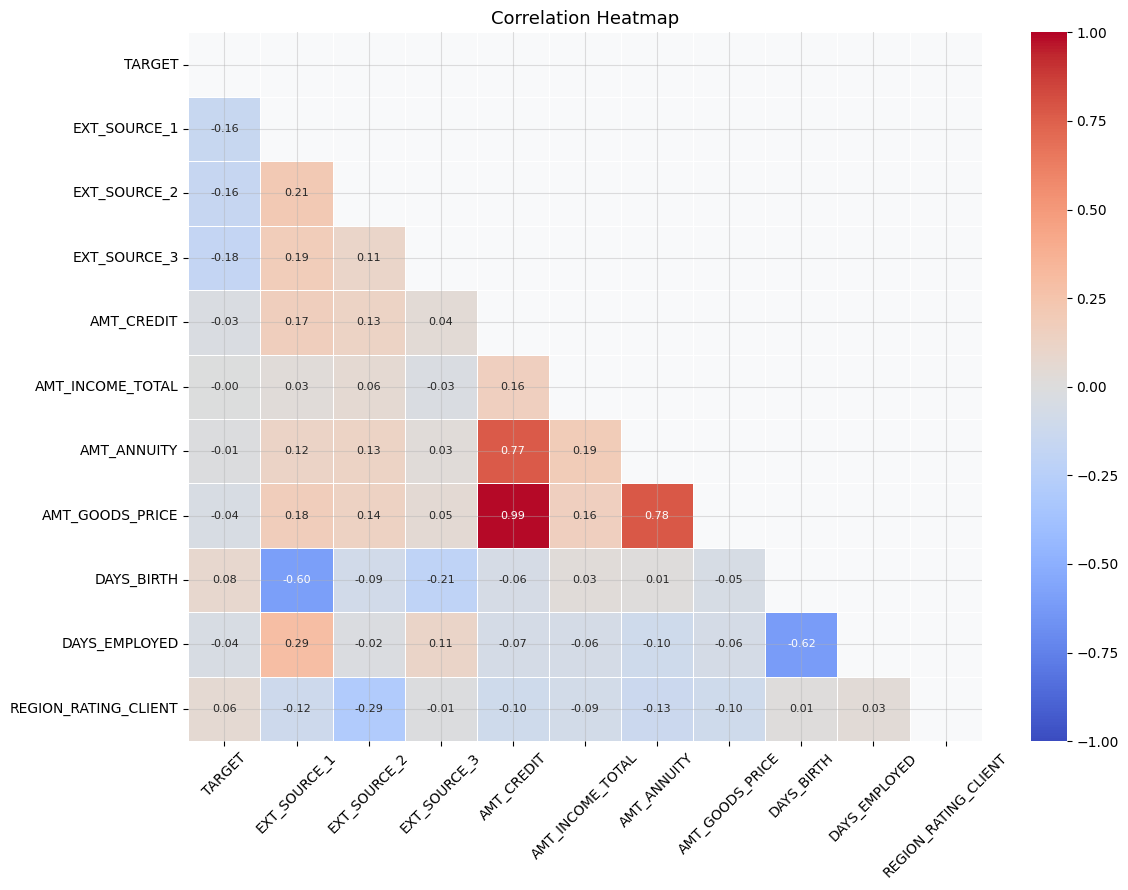

In [16]:
# Correlation heatmap (selected features)
heatmap_cols = [
    'TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'REGION_RATING_CLIENT',
]
heatmap_cols = [c for c in heatmap_cols if c in app_train.columns]

corr_matrix = app_train[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 8},
    ax=ax
)

ax.set_title('Correlation Heatmap', fontsize=13)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(p('eda_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

---

## SECTION 7 — External Tables Deep Dive

Bureau Analysis
------------------------------
Customers with bureau records: 305,811 / 307,511
Avg records per customer: 5.6
Max records: 116


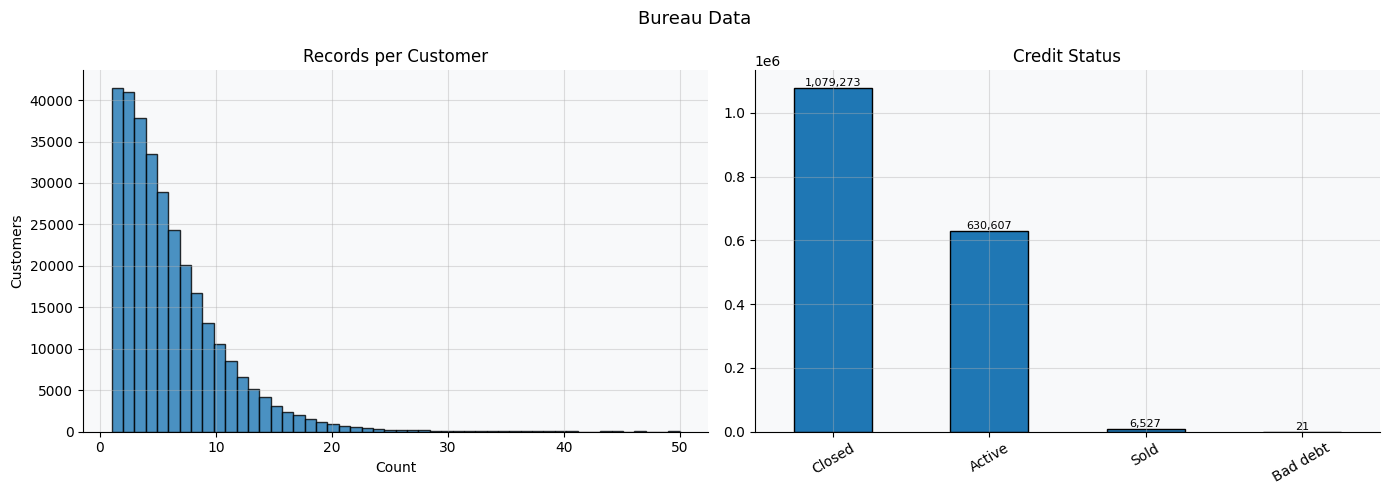

In [17]:
# Bureau analysis
print('Bureau Analysis')
print('-' * 30)

# Loans per customer
bureau_per_client = bureau.groupby('SK_ID_CURR').size()

print(f'Customers with bureau records: {bureau["SK_ID_CURR"].nunique():,} / {app_train["SK_ID_CURR"].nunique():,}')
print(f'Avg records per customer: {bureau_per_client.mean():.1f}')
print(f'Max records: {bureau_per_client.max()}')

# Credit status distribution
credit_status = bureau['CREDIT_ACTIVE'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bureau Data', fontsize=13)

# Records per customer
axes[0].hist(
    bureau_per_client.clip(0, 50),
    bins=50,
    edgecolor='black',
    alpha=0.8
)
axes[0].set_title('Records per Customer')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Customers')

# Credit status
credit_status.plot(
    kind='bar',
    ax=axes[1],
    edgecolor='black'
)

axes[1].set_title('Credit Status')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)

for bar in axes[1].patches:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        h,
        f'{h:,.0f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

plt.tight_layout()
plt.savefig(p('eda_bureau_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

Previous Application Analysis
-----------------------------------
Customers with previous applications: 338,857
Avg applications per customer: 4.9

Contract status:
Approved: 1,036,781 (62.1%)
Canceled: 316,319 (18.9%)
Refused: 290,678 (17.4%)
Unused offer: 26,436 (1.6%)

Approval rate by TARGET:
0: 63.4%
1: 55.0%


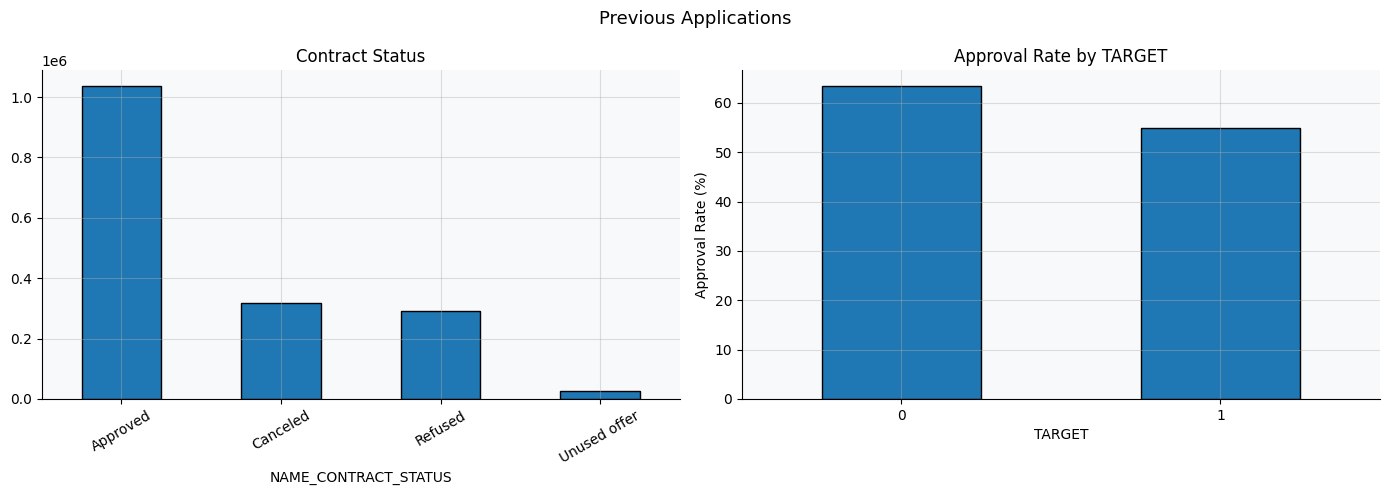

In [18]:
# Previous application analysis
print('Previous Application Analysis')
print('-' * 35)

prev_per_client = prev_app.groupby('SK_ID_CURR').size()

print(f'Customers with previous applications: {prev_app["SK_ID_CURR"].nunique():,}')
print(f'Avg applications per customer: {prev_per_client.mean():.1f}')

# Contract status
status_counts = prev_app['NAME_CONTRACT_STATUS'].value_counts()

print('\nContract status:')
for k, v in status_counts.items():
    print(f'{k}: {v:,} ({100*v/len(prev_app):.1f}%)')

# Approval rate by TARGET
prev_with_target = prev_app.merge(
    app_train[['SK_ID_CURR', 'TARGET']],
    on='SK_ID_CURR',
    how='left'
)

approval_by_target = (
    prev_with_target.groupby('TARGET')['NAME_CONTRACT_STATUS']
    .apply(lambda x: (x == 'Approved').mean() * 100)
)

print('\nApproval rate by TARGET:')
print(f'0: {approval_by_target.get(0, 0):.1f}%')
print(f'1: {approval_by_target.get(1, 0):.1f}%')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Previous Applications', fontsize=13)

# Status distribution
status_counts.plot(
    kind='bar',
    ax=axes[0],
    edgecolor='black'
)
axes[0].set_title('Contract Status')
axes[0].tick_params(axis='x', rotation=30)

# Approval rate
approval_by_target.plot(
    kind='bar',
    ax=axes[1],
    edgecolor='black'
)
axes[1].set_title('Approval Rate by TARGET')
axes[1].set_ylabel('Approval Rate (%)')
axes[1].set_xticklabels(['0', '1'], rotation=0)

plt.tight_layout()
plt.savefig(p('eda_prev_app_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

Installments Analysis
------------------------------
Late payment rate: 8.4%
Avg payment ratio: 0.957

Late payment rate by TARGET:
0: 8.4%
1: 11.0%


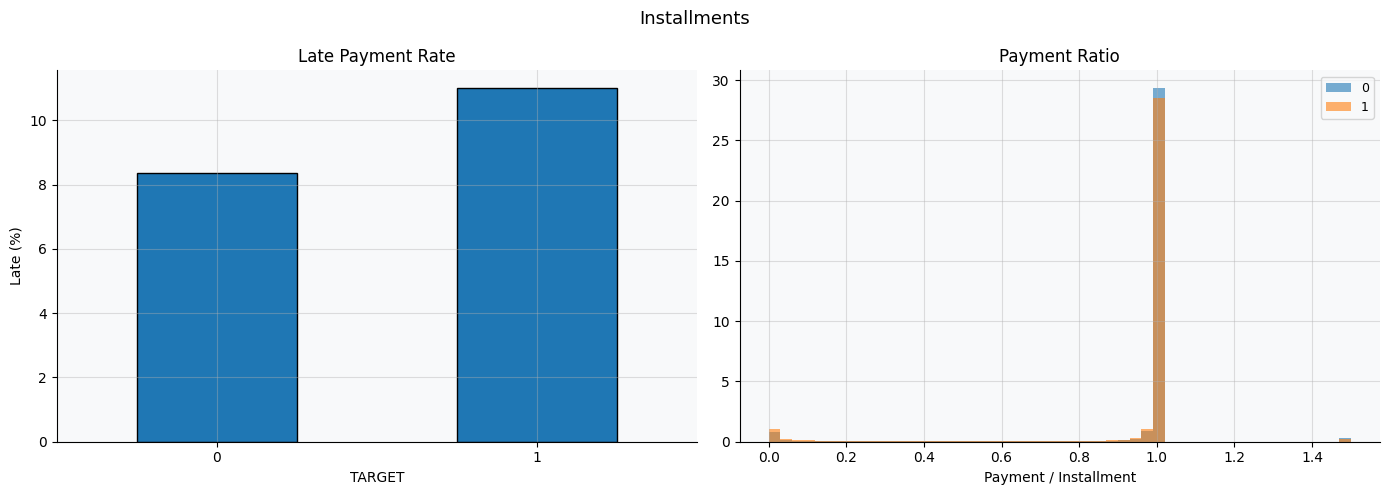

In [19]:
# Installments — payment behavior
print('Installments Analysis')
print('-' * 30)

inst = installments.copy()
inst['DAYS_BEFORE_DUE'] = inst['DAYS_INSTALMENT'] - inst['DAYS_ENTRY_PAYMENT']
inst['IS_LATE'] = (inst['DAYS_BEFORE_DUE'] < 0).astype(int)
inst['PAYMENT_RATIO'] = inst['AMT_PAYMENT'] / (inst['AMT_INSTALMENT'] + 1)

late_rate = inst['IS_LATE'].mean() * 100
print(f'Late payment rate: {late_rate:.1f}%')
print(f'Avg payment ratio: {inst["PAYMENT_RATIO"].clip(0, 2).mean():.3f}')

# Join with TARGET
inst_with_target = inst.merge(
    app_train[['SK_ID_CURR', 'TARGET']],
    on='SK_ID_CURR',
    how='left'
)

late_by_target = inst_with_target.groupby('TARGET')['IS_LATE'].mean() * 100
pay_ratio_by_target = inst_with_target.groupby('TARGET')['PAYMENT_RATIO'].median()

print('\nLate payment rate by TARGET:')
print(f'0: {late_by_target.get(0, 0):.1f}%')
print(f'1: {late_by_target.get(1, 0):.1f}%')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Installments', fontsize=13)

# Late payment rate
late_by_target.plot(
    kind='bar',
    ax=axes[0],
    edgecolor='black'
)
axes[0].set_title('Late Payment Rate')
axes[0].set_ylabel('Late (%)')
axes[0].set_xticklabels(['0', '1'], rotation=0)

# Payment ratio distribution
d0 = inst_with_target.loc[inst_with_target['TARGET'] == 0, 'PAYMENT_RATIO'].clip(0, 1.5)
d1 = inst_with_target.loc[inst_with_target['TARGET'] == 1, 'PAYMENT_RATIO'].clip(0, 1.5)

axes[1].hist(d0, bins=50, alpha=0.6, density=True, label='0')
axes[1].hist(d1, bins=50, alpha=0.6, density=True, label='1')

axes[1].set_title('Payment Ratio')
axes[1].set_xlabel('Payment / Installment')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(p('eda_installments_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()